---
title: Homework Module 1 — DFT of a Hardcoded Time Array
---

*Built with Grok Build*

Course: **EEE591 / EEE419 Python for Rapid Engineering Solutions**.

This notebook is an **executable walkthrough** of `hw1_591.py`. Code is split into logical groups.
After each group runs, its output appears below. Lines that were previously commented out for
strict assignment grading are **enabled here** so intermediate results are visible and instructive.


## Setup

Import NumPy and choose the DFT length $N$. Larger $N$ makes the nested-loop DFT slower
($O(N^2)$), so we keep $N = 512$ as in the assignment solution (you can try 8 for a quick debug).

In [2]:
import numpy as np

# Number of samples / DFT length
# N = 8      # small value for quick debugging
N = 512
# N = 2048   # slower nested-loop DFT

print(f"Using N = {N} samples")


Using N = 512 samples


## Build a reproducible random time-domain signal

We fix the random seed so re-running the notebook produces the same `x_time` array, then
draw $N$ samples uniformly from $[0, 1)$.

In [3]:
# Define random seed for reproducibility
np.random.seed(0)

# Generate random time array of length N
x_time = np.random.rand(N)

print(f"x_time shape: {x_time.shape}, dtype: {x_time.dtype}")
print(f"x_time (first 8 samples): {x_time[:8]}")
print(f"x_time mean={x_time.mean():.6f}, min={x_time.min():.6f}, max={x_time.max():.6f}")


x_time shape: (512,), dtype: float64
x_time (first 8 samples): [0.5488135  0.71518937 0.60276338 0.54488318 0.4236548  0.64589411
 0.43758721 0.891773  ]
x_time mean=0.495272, min=0.004695, max=0.998847


## Method 1 — DFT with nested `for` loops

This implements the definition of the discrete Fourier transform:

$$
X[k] = \sum_{n=0}^{N-1} x[n] \, e^{-j 2\pi k n / N}
$$

The result array is **complex** so each bin can hold magnitude and phase information.

In [4]:
# Initialize DFT array with zeros (complex for mag + phase)
x_freq_loops = np.zeros(N, dtype=complex)

# Compute DFT using nested for loops
for k in range(N):          # frequency bins
    for n in range(N):      # time samples
        x_freq_loops[k] += x_time[n] * np.exp(-(2j * np.pi * k * n) / N)

print(f"type(x_freq_loops) = {type(x_freq_loops)}")
print(f"x_freq_loops dtype = {x_freq_loops.dtype}, shape = {x_freq_loops.shape}")
print(f"x_freq_loops (first 5 bins):\n{x_freq_loops[:5]}")


type(x_freq_loops) = <class 'numpy.ndarray'>
x_freq_loops dtype = complex128, shape = (512,)
x_freq_loops (first 5 bins):
[253.57935888+0.j           2.16755786-0.69216714j
   0.74623182+4.12529531j   2.82434059+6.33791417j
  12.90559662+0.74393187j]


## Method 2 — DFT via matrix multiplication

Build the DFT matrix $W$ with entries

$$
W_{kn} = e^{-j 2\pi k n / N}
$$

then compute $X = W x$ with a single matrix–vector product. This is still $O(N^2)$ work, but
uses NumPy’s vectorized linear algebra instead of explicit Python loops.

In [5]:
# Create the DFT matrix
n = np.arange(N)              # time indices (row)
k = n.reshape((N, 1))         # frequency indices (column)

# Outer product form of the DFT kernel
W = np.exp(-(2j * np.pi * k * n) / N)   # shape (N, N)

# DFT by matrix multiplication
x_freq_matrix = np.dot(W, x_time)

print(f"type(x_freq_matrix) = {type(x_freq_matrix)}")
print(f"W shape = {W.shape}, x_freq_matrix shape = {x_freq_matrix.shape}")
print(f"x_freq_matrix (first 5 bins):\n{x_freq_matrix[:5]}")


type(x_freq_matrix) = <class 'numpy.ndarray'>
W shape = (512, 512), x_freq_matrix shape = (512,)
x_freq_matrix (first 5 bins):
[253.57935888+0.j           2.16755786-0.69216714j
   0.74623182+4.12529531j   2.82434059+6.33791417j
  12.90559662+0.74393187j]


## Method 3 — DFT with NumPy’s FFT

`np.fft.fft` uses a Fast Fourier Transform ($O(N \log N)$) and is the practical reference
implementation we compare against.

In [6]:
x_freq_fft = np.fft.fft(x_time)

print(f"type(x_freq_fft) = {type(x_freq_fft)}")
print(f"x_freq_fft dtype = {x_freq_fft.dtype}, shape = {x_freq_fft.shape}")
print(f"x_freq_fft (first 5 bins):\n{x_freq_fft[:5]}")


type(x_freq_fft) = <class 'numpy.ndarray'>
x_freq_fft dtype = complex128, shape = (512,)
x_freq_fft (first 5 bins):
[253.57935888+0.j           2.16755786-0.69216714j
   0.74623182+4.12529531j   2.82434059+6.33791417j
  12.90559662+0.74393187j]


## Compare magnitudes

Convert each complex spectrum to a magnitude spectrum $|X[k]|$, inspect a few bins, then
form average magnitude errors of the loop and matrix results relative to the FFT.

In [7]:
# Magnitudes
x_freq_loops_mag = np.abs(x_freq_loops)
x_freq_matrix_mag = np.abs(x_freq_matrix)
x_freq_fft_mag = np.abs(x_freq_fft)

print("x_freq_loops_mag  (first 5):", x_freq_loops_mag[:5])
print("x_freq_matrix_mag (first 5):", x_freq_matrix_mag[:5])
print("x_freq_fft_mag    (first 5):", x_freq_fft_mag[:5])


x_freq_loops_mag  (first 5): [253.57935888   2.27539061   4.19224562   6.93873589  12.92702048]
x_freq_matrix_mag (first 5): [253.57935888   2.27539061   4.19224562   6.93873589  12.92702048]
x_freq_fft_mag    (first 5): [253.57935888   2.27539061   4.19224562   6.93873589  12.92702048]


## Errors vs the FFT reference

We report the mean (over bins) difference of magnitudes. Values near machine precision mean
the educational implementations agree with `np.fft.fft` for this signal.

In [8]:
print("Calculating average magnitude errors vs numpy FFT...")

error_loops_fft = np.sum(x_freq_loops_mag - x_freq_fft_mag) / N
error_matrix_fft = np.sum(x_freq_matrix_mag - x_freq_fft_mag) / N

print(f"Max error (loop   vs FFT): {error_loops_fft:.2e}")
print(f"Max error (matrix vs FFT): {error_matrix_fft:.2e}")

# Extra diagnostics (instructive; not required for original grading)
print()
print(f"Max |loop - FFT|   bin error: {np.max(np.abs(x_freq_loops - x_freq_fft)):.2e}")
print(f"Max |matrix - FFT| bin error: {np.max(np.abs(x_freq_matrix - x_freq_fft)):.2e}")
print(f"Relative max |loop - FFT| / max|FFT|: "
      f"{np.max(np.abs(x_freq_loops - x_freq_fft)) / np.max(np.abs(x_freq_fft)):.2e}")


Calculating average magnitude errors vs numpy FFT...
Max error (loop   vs FFT): 1.97e-14
Max error (matrix vs FFT): 1.97e-14

Max |loop - FFT|   bin error: 1.65e-11
Max |matrix - FFT| bin error: 1.65e-11
Relative max |loop - FFT| / max|FFT|: 6.50e-14


## Optional plot — first 64 magnitude bins

A quick visual check that all three methods overlie each other (they should look identical at this scale).

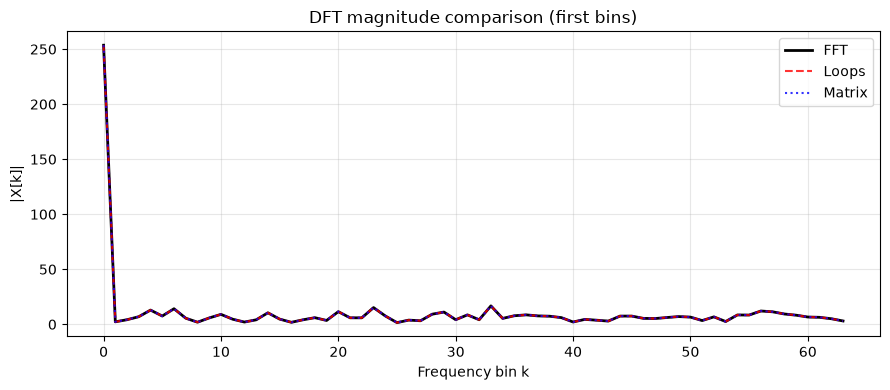

In [9]:
import matplotlib.pyplot as plt

bins = np.arange(min(64, N))
plt.figure(figsize=(9, 4))
plt.plot(bins, x_freq_fft_mag[bins], 'k-', linewidth=2, label='FFT')
plt.plot(bins, x_freq_loops_mag[bins], 'r--', alpha=0.8, label='Loops')
plt.plot(bins, x_freq_matrix_mag[bins], 'b:', alpha=0.8, label='Matrix')
plt.xlabel('Frequency bin k')
plt.ylabel('|X[k]|')
plt.title('DFT magnitude comparison (first bins)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Takeaways

- The **definitional nested-loop DFT** and the **matrix form** match NumPy’s **FFT** to high accuracy.
- Loops and dense matrix DFTs are fine for learning, but scale poorly; FFT is what you want in real engineering work.
- Intermediate prints (types, first bins, magnitudes) make it easier to debug shape/`dtype` mistakes early.

The original script `hw1_591.py` remains in this folder if you want a single-file CLI version.